
# Introduction
<p align="center">
<img src="https://raw.githubusercontent.com/pbcquoc/vietocr/master/image/vietocr.jpg" width="512" height="512">
</p>
This notebook describe how you can use VietOcr to train OCR model




In [1]:
! pip install --quiet vietocr

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.9/133.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 123.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.0/303.0 kB 28.4 MB/s eta 0:00:00


# Inference

In [1]:
# !pip install pillow==10.2.0 --force-reinstall
# !pip install vietocr==0.3.13 --force-reinstall
# !pip install scikit-image==0.25.2
import matplotlib.pyplot as plt
from PIL import Image

from vietocr.tool.predictor import Predictor
from vietocr.tool.config import Cfg

In [2]:
config = Cfg.load_config_from_name('vgg_transformer')

Change weights to your weights or using default weights from our pretrained model. Path can be url or local file

In [3]:
# config['weights'] = './weights/transformerocr.pth'
config['cnn']['pretrained']=False
config['device'] = 'cuda:0'

In [4]:
detector = Predictor(config)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
18533it [00:10, 1820.45it/s]


In [5]:
! wget https://vocr.vn/data/vietocr/sample.zip
! unzip  -qq -o sample.zip

--2025-09-16 08:03:57--  https://vocr.vn/data/vietocr/sample.zip
Resolving vocr.vn (vocr.vn)... 128.199.222.116
Connecting to vocr.vn (vocr.vn)|128.199.222.116|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 305969 (299K) [application/zip]
Saving to: ‘sample.zip’

sample.zip          100%[===================>] 298.80K   598KB/s    in 0.5s    

2025-09-16 08:03:58 (598 KB/s) - ‘sample.zip’ saved [305969/305969]



In [6]:
! ls sample | shuf |head -n 5

58788.jpg
072084003708.jpeg
deskewed-2019_09_16_nguyen_thi_hoai_thanh_2019091614580813_18.jpg
001063014772.jpeg
072077001591.jpeg


'29'

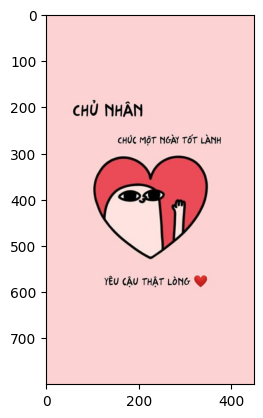

In [15]:
img = '/content/hinh-nen-cute-co-chu-34.jpg'
img = Image.open(img)
plt.imshow(img)
s = detector.predict(img)
s

'038071004740'

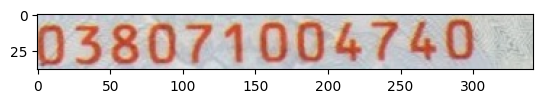

In [14]:
img = '/content/sample/038071004740.jpeg'
img = Image.open(img)
plt.imshow(img)
s = detector.predict(img)
s

'Started'

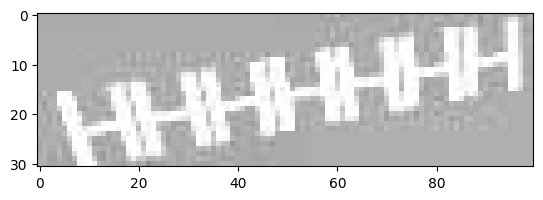

In [16]:
img = '/content/sample/461_PIGTAIL_57575.jpg'
img = Image.open(img)
plt.imshow(img)
s = detector.predict(img)
s

'MONIKER'

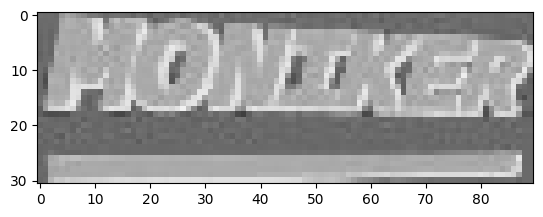

In [17]:
img = '/content/sample/466_MONIKER_49537.jpg'
img = Image.open(img)
plt.imshow(img)
s = detector.predict(img)
s

'BSCKII. LƯU CÔNG THÀNH'

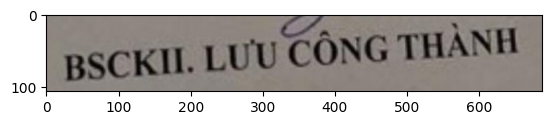

In [18]:
img = '/content/sample/deskewed-_2019_10_03_20191003002690_2019100308491067310_4.jpg'
img = Image.open(img)
plt.imshow(img)
s = detector.predict(img)
s